## Model Loading

In [33]:
import torch
from pathlib import Path
import sys

root_dir = Path('/home/eungyeop/LLM/tabular/ProtoLLM_entropic20251217')
sys.path.append(str(root_dir))

from models.TabularFLM_S_ import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = '/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/best_joint.pt'
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id='viz',
    mode='viz'
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

model.eval()

Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

## Source Loading

In [34]:
args2 = args
fix_seed(args2.random_seed)

sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f'Loading dataloader for source: {src}')
    res = prepare_embedding_dataloaders(args2, src, is_source=True)
    tr, va, te = res['loaders']

    from torch.utils.data import ConcatDataset, DataLoader
    datasets = [l.dataset for l in [tr, va, te] if l is not None]
    ds = ConcatDataset(datasets)

    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)

>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 1121
[Source] Validation data size: 198
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 850
[Source] Validation data size: 150
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 229
[Source] Va

## Helpers: load tabular, one-hot basis risk, TP/TN extraction

In [35]:
import numpy as np
import pandas as pd
import torch.nn.functional as F

base_table_path = '/storage/personal/eungyeop/dataset/table/origin_table'

dataset_and_class = {
    'heart': ['target_binary', ['no','yes']],
    'Cardiovascular_Disease_Dataset': ['target_binary', ['no', 'yes']],
    'Medicaldataset': ['target_binary', ['no', 'yes']],
    'Heart_disease_statlog': ['target_binary', ['no','yes']],
    'Erbil_Cardiovascular_Health_Dataset': ['target_binary', ['no','yes']],
    'cardio_SAheart': ['target_binary', ['no','yes']],
    'heart_failure_clinical_records': ['target_binary', ['no','yes']],
}

label_col_map = {
    'Cardiovascular_Disease_Dataset': 'target',
    'Medicaldataset': 'Result',
    'heart1': 'output',
}

def load_original_tabular(dataset_name):
    csv_path = f'{base_table_path}/{dataset_name}.csv'
    df = pd.read_csv(csv_path)
    class_info = dataset_and_class.get(dataset_name)
    if class_info is None:
        for col in ['target_binary', 'target', 'Result', 'output', 'target_multiclass']:
            if col in df.columns:
                y = df[col]; X = df.drop(col, axis=1)
                return X.reset_index(drop=True), y.reset_index(drop=True)
        raise ValueError(f'Cannot find label column for {dataset_name}')
    class_name = class_info[0]
    if dataset_name in label_col_map:
        orig_col = label_col_map[dataset_name]
        if orig_col in df.columns:
            df[class_name] = df[orig_col]; df = df.drop(orig_col, axis=1)
    if class_name in df.columns:
        X = df.drop(class_name, axis=1); y = df[class_name]
    else:
        raise ValueError(f"Label column '{class_name}' not found")
    return X.reset_index(drop=True), y.reset_index(drop=True)


@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    expert_outputs = model.gnn_experts(lcg_feat.unsqueeze(0), lcg_struct.unsqueeze(0))

    onehot_probs = []
    for k in range(M):
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)
        current_mode = getattr(model, 'mode', 'Full')
        logit = model.ghead2(weighted) if current_mode == 'Few' else model.ghead(weighted)
        onehot_probs.append(torch.sigmoid(logit).item())

    print('One-Hot Basis Risk:')
    for k in range(M):
        label = 'HIGH' if onehot_probs[k] > 0.5 else 'LOW'
        print(f'  B{k}: {onehot_probs[k]:.4f} -> {label}')
    return np.array(onehot_probs)


@torch.no_grad()
def extract_tp_tn_with_tabular(model, loader, device, dataset_name):
    model.eval()
    X_orig, y_orig = load_original_tabular(dataset_name)
    all_pi, all_y, all_prob, all_sidx = [], [], [], []

    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        out = model.predict(batch_t, return_all=True)
        global_pred = out[0] if isinstance(out, tuple) else out
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor): all_sidx.append(sidx.cpu().view(-1).numpy())
            else: all_sidx.append(np.array([sidx] * pi.shape[0]))
        else:
            start = sum(len(s) for s in all_sidx)
            all_sidx.append(np.arange(start, start + pi.shape[0]))

    pis = np.concatenate(all_pi); ys = np.concatenate(all_y).astype(int)
    probs = np.concatenate(all_prob); sidxs = np.concatenate(all_sidx).astype(int)
    preds = (probs >= 0.5).astype(int)
    valid = sidxs < len(X_orig)
    if not valid.all():
        pis, ys, probs, sidxs, preds = pis[valid], ys[valid], probs[valid], sidxs[valid], preds[valid]

    tp = (ys == 1) & (preds == 1); tn = (ys == 0) & (preds == 0)
    fp = (ys == 0) & (preds == 1); fn = (ys == 1) & (preds == 0)
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)

    print(f'[{dataset_name}] N={len(ys)}, TP={tp.sum()}, TN={tn.sum()}, FP={fp.sum()}, FN={fn.sum()}')
    return {'dataset_name': dataset_name, 'X': X_mapped, 'pis': pis, 'ys': ys,
            'probs': probs, 'preds': preds, 'argmax': pis.argmax(axis=1),
            'tp_mask': tp, 'tn_mask': tn, 'fp_mask': fp, 'fn_mask': fn}

## Build `onehot_probs` and `all_results`

In [36]:
onehot_probs = compute_onehot_basis_risk(model, device)

all_results = {}
for src_name in sources:
    all_results[src_name] = extract_tp_tn_with_tabular(model, loaders[src_name], device, src_name)

One-Hot Basis Risk:
  B0: 0.0240 -> LOW
  B1: 0.9376 -> HIGH
  B2: 0.8102 -> HIGH
  B3: 0.2489 -> LOW
  B4: 0.4552 -> LOW
  B5: 0.0379 -> LOW
  B6: 0.8174 -> HIGH
  B7: 0.9943 -> HIGH
[Medicaldataset] N=1319, TP=698, TN=378, FP=131, FN=112
[Cardiovascular_Disease_Dataset] N=1000, TP=555, TN=241, FP=179, FN=25
[Heart_disease_statlog] N=270, TP=96, TN=98, FP=52, FN=24
[Erbil_Cardiovascular_Health_Dataset] N=287, TP=93, TN=174, FP=11, FN=9
[cardio_SAheart] N=462, TP=82, TN=227, FP=75, FN=78
[heart_failure_clinical_records] N=299, TP=81, TN=161, FP=42, FN=15


## Signed Effect Size: elevated-above-population radar

목표: '이 risk group이 population 대비 risk factor를 **얼마나 위로 끌어올렸는지**'.

- **Reference** = **전체 population** (basis 포함). Basis마다 reference가 바뀌지 않아 비교가 일관됨
- **Numerical**: signed Cohen's d = (mean_g − mean_pop) / pooled_SD (양수 = basis > pop)
- **Categorical**: Cramér's V (방향 없음, V ≥ 0)
- **Feature ranking**: `Σ max(0, d)` — "어느 basis에서든 elevated" feature를 상위로
- **Radar plot**: `max(0, signed_d)` → 음수(= basis가 pop보다 낮음)는 0으로 클램프
  - H basis: risk factor 올린 feature만 볼록
  - L basis: risk factor 낮춘 feature는 0에 수렴

Categorical V는 여전히 방향성 없음 → L도 categorical에선 찍힐 수 있음 (한계).

In [37]:
from scipy.stats import chi2_contingency

EXCLUDE_FEATURES = {'patientid', 'patient_id', 'id', 'ID', 'time'}


def detect_feature_type(X, col, max_unique_cat=10):
    s = X[col]
    if s.dtype == 'object' or str(s.dtype).startswith('category'):
        return 'categorical'
    nunq = s.nunique(dropna=True)
    if nunq <= max_unique_cat:
        return 'categorical'
    return 'numerical'


def cohen_d_numerical(group_vals, ref_vals):
    """SIGNED Cohen's d: 양수 = group mean > reference mean.
    ref는 전체 population (group 포함 가능). 소수 group이면 차이 미미, 다수 group이면 pooled_SD가 안정화."""
    g = pd.to_numeric(pd.Series(group_vals), errors='coerce').dropna().values
    r = pd.to_numeric(pd.Series(ref_vals), errors='coerce').dropna().values
    ng, nr = len(g), len(r)
    if ng < 2 or nr < 2:
        return 0.0
    vg = g.var(ddof=1) if ng > 1 else 0.0
    vr = r.var(ddof=1) if nr > 1 else 0.0
    pooled_var = ((ng - 1) * vg + (nr - 1) * vr) / (ng + nr - 2)
    if pooled_var <= 0:
        return 0.0
    d = (g.mean() - r.mean()) / np.sqrt(pooled_var)
    if np.isnan(d) or np.isinf(d):
        return 0.0
    return float(d)


def cramer_v_categorical(group_vals, ref_vals):
    """Cramér's V — 방향 없음. ref는 전체 population (group 포함)."""
    g = pd.Series(group_vals).dropna().astype(str).values
    r = pd.Series(ref_vals).dropna().astype(str).values
    if len(g) < 2 or len(r) < 2:
        return 0.0
    cats = np.unique(np.concatenate([g, r]))
    if len(cats) < 2:
        return 0.0
    g_counts = np.array([(g == c).sum() for c in cats])
    r_counts = np.array([(r == c).sum() for c in cats])
    table = np.vstack([g_counts, r_counts])
    nonzero = table.sum(axis=0) > 0
    table = table[:, nonzero]
    if table.shape[1] < 2 or table.sum() == 0:
        return 0.0
    try:
        chi2, p, dof, ex = chi2_contingency(table)
    except Exception:
        return 0.0
    n = table.sum()
    r_dim, c_dim = table.shape
    min_dim = min(r_dim - 1, c_dim - 1)
    if min_dim <= 0 or n <= 0 or np.isnan(chi2):
        return 0.0
    v = np.sqrt(chi2 / (n * min_dim))
    if np.isnan(v) or np.isinf(v):
        return 0.0
    return float(min(v, 1.0))


def compute_basis_effect_scores(result, min_n=5):
    """각 basis vs **전체 population** 비교. Reference 고정이라 basis 간 비교 일관됨.
    numerical=signed d, categorical=unsigned V."""
    X = result['X']
    argmax = result['argmax']
    M = result['pis'].shape[1]

    feat_types = {}
    for c in X.columns:
        if c.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        feat_types[c] = detect_feature_type(X, c)

    scores, group_sizes = {}, {}
    for k in range(M):
        mask = (argmax == k)
        n = int(mask.sum())
        if n < min_n:
            continue
        group_sizes[k] = n
        scores[k] = {}
        for col, ft in feat_types.items():
            g = X.loc[mask, col].values
            r = X[col].values  # 전체 population (basis 포함)
            if ft == 'numerical':
                scores[k][col] = cohen_d_numerical(g, r)
            else:
                scores[k][col] = cramer_v_categorical(g, r)
    return scores, feat_types, group_sizes


def select_top_features(scores, k_features=8, agg='sum'):
    """Σ max(0, v) 로 ranking."""
    all_feats = set()
    for k in scores:
        all_feats.update(scores[k].keys())
    agg_scores = {}
    for f in all_feats:
        vals = [max(0.0, scores[k].get(f, 0.0)) for k in scores]
        if not vals:
            continue
        if agg == 'max':
            agg_scores[f] = max(vals)
        elif agg == 'mean':
            agg_scores[f] = float(np.mean(vals))
        else:
            agg_scores[f] = float(np.sum(vals))
    ranked = sorted(agg_scores.items(), key=lambda x: -x[1])
    return [f for f, s in ranked[:k_features]], agg_scores

## KL-divergence Radar

**값**: `KL(p_basis ‖ q_pop)` — LCG k 에 속하는 샘플의 feature 분포가 전체 population 대비 얼마나 벌어져 있는지
- **Numerical**: population 기준 quantile binning (B=10), Laplace smoothing (ε=1e-6)
- **Categorical**: 각 카테고리 카운트, Laplace smoothing

**샘플**: `argmax == k` 전체 (TP/TN 필터 없음, LCG 소속 = 기준)
**Reference**: 전체 population (basis 포함 — basis 간 비교 일관)
**Normalize**: per-feature max → [0, 1] (각 축 독립 스케일)
**선**: H (onehot > 0.5) = solid / L = dashed

KL 은 unsigned ≥ 0 이라 방향은 없음. 'H 가 elevated / L 은 중심' 패턴을 기대하려면 KL 이 아니라 signed metric 이 필요하니 참고.


[Medicaldataset] raw KL(p_basis || q_pop):
basis               |     Troponin |          Age | Systolic blo |  Blood sugar |        CK-MB | Diastolic bl |   Heart rate |       Gender
B0[L](n=127 ) |        0.434 |        0.218 |        0.109 |        0.059 |        0.393 |        0.157 |        0.206 |        0.000
B1[H](n=23  ) |        0.772 |        1.227 |        0.782 |        0.677 |        0.337 |        0.161 |        0.215 |        0.003
B3[L](n=104 ) |        0.295 |        0.372 |        0.187 |        0.054 |        0.660 |        0.208 |        0.179 |        0.027
B4[L](n=449 ) |        0.279 |        0.031 |        0.076 |        0.015 |        0.153 |        0.134 |        0.022 |        0.002
B5[L](n=85  ) |        0.304 |        0.196 |        0.226 |        0.127 |        0.701 |        0.179 |        0.154 |        0.005
B6[H](n=447 ) |        0.256 |        0.032 |        0.083 |        0.025 |        0.093 |        0.123 |        0.045 |        0.005
B7[H](n=84  

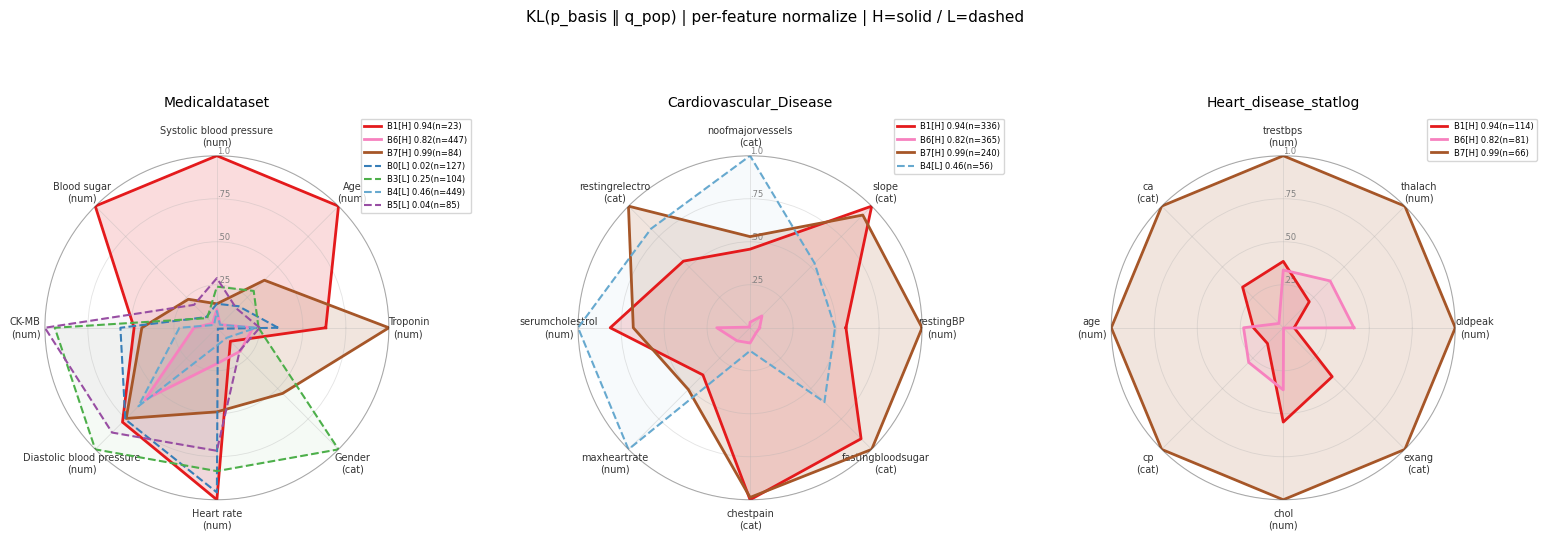


[Erbil_Cardiovascular_Health] raw KL(p_basis || q_pop):
basis               |       HEIGHT |   HEART_RATE | BLOOD_PRESSU | BLOOD_PRESSU |       WEIGHT |          AGE |          SEX | LDL_CHOLESTE
B2[H](n=23  ) |        0.491 |        0.466 |        0.414 |        0.363 |        0.316 |        0.265 |        0.257 |        0.213
B4[L](n=6   ) |        1.054 |        0.898 |        0.392 |        0.544 |        0.712 |        1.196 |        0.001 |        1.310
B5[L](n=7   ) |        0.545 |        0.717 |        0.346 |        1.077 |        1.185 |        1.110 |        0.656 |        0.986
B6[H](n=243 ) |        0.003 |        0.005 |        0.005 |        0.004 |        0.002 |        0.007 |        0.001 |        0.001

[cardio_SAheart] raw KL(p_basis || q_pop):
basis               |          AGE | SYSTOLIC_BLO |      OBESITY |    ADIPOSITY | CUMULATIVE_T | LDL_CHOLESTE | ALCOHOL_CONS | TYPE_A_BEHAV
B0[L](n=82  ) |        0.195 |        0.187 |        0.119 |        0.172 |        

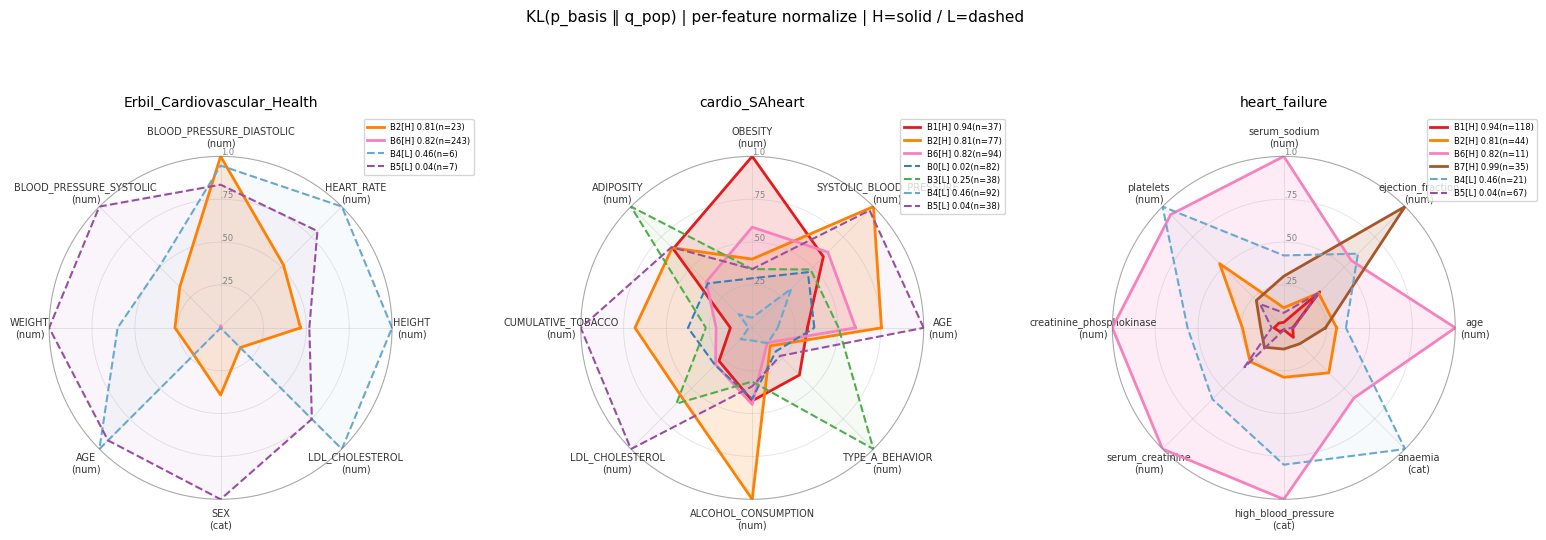

In [38]:
import matplotlib.pyplot as plt

BASIS_COLORS = {
    'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
    'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
}

EPS = 1e-6


def _pop_spec(X, feat_types, n_bins=10):
    """Population quantile edges (num) / unique cats (cat) + q_pop 분포."""
    spec = {}
    for col, ft in feat_types.items():
        if ft == 'numerical':
            v = pd.to_numeric(X[col], errors='coerce').values
            v = v[~np.isnan(v)]
            if len(v) < max(n_bins, 10):
                continue
            edges = np.unique(np.quantile(v, np.linspace(0, 1, n_bins + 1)))
            if len(edges) < 3:
                continue
            counts, _ = np.histogram(v, bins=edges)
            q = counts.astype(float) + EPS
            q /= q.sum()
            spec[col] = {'type': 'numerical', 'edges': edges, 'q_pop': q}
        else:
            s = pd.Series(X[col]).astype(str).fillna('__nan__')
            cats = np.array(sorted(s.unique()))
            if len(cats) < 2:
                continue
            counts = np.array([(s.values == c).sum() for c in cats], dtype=float)
            q = counts + EPS
            q /= q.sum()
            spec[col] = {'type': 'categorical', 'cats': cats, 'q_pop': q}
    return spec


def _basis_p(X, col, sc, mask):
    if sc['type'] == 'numerical':
        v = pd.to_numeric(X.loc[mask, col], errors='coerce').values
        v = v[~np.isnan(v)]
        if len(v) == 0:
            return None
        counts, _ = np.histogram(v, bins=sc['edges'])
    else:
        s = pd.Series(X.loc[mask, col]).astype(str).fillna('__nan__')
        if len(s) == 0:
            return None
        counts = np.array([(s.values == c).sum() for c in sc['cats']], dtype=float)
    p = counts.astype(float) + EPS
    p /= p.sum()
    return p


def _kl(p, q):
    return float(np.sum(p * np.log(p / q)))


def compute_basis_kl(result, onehot_probs, min_n=5, n_bins=10):
    X = result['X']
    argmax = result['argmax']
    M = result['pis'].shape[1]

    feat_types = {}
    for c in X.columns:
        if c.lower() in {f.lower() for f in EXCLUDE_FEATURES}:
            continue
        feat_types[c] = detect_feature_type(X, c)

    spec = _pop_spec(X, feat_types, n_bins=n_bins)

    scores, sizes, is_high = {}, {}, {}
    for k in range(M):
        mask = (argmax == k)
        n = int(mask.sum())
        if n < min_n:
            continue
        sizes[k] = n
        is_high[k] = onehot_probs[k] > 0.5
        scores[k] = {}
        for col, sc in spec.items():
            p = _basis_p(X, col, sc, mask)
            if p is None:
                continue
            scores[k][col] = _kl(p, sc['q_pop'])
    return scores, feat_types, sizes, is_high


def _select_topk_kl(scores, is_high, k_features=8):
    ref = [k for k in scores if is_high[k]] or list(scores.keys())
    feats = set()
    for k in scores:
        feats.update(scores[k].keys())
    agg = {}
    for f in feats:
        vals = [scores[k].get(f, 0.0) for k in ref]
        if vals:
            agg[f] = float(np.mean(vals))
    return [f for f, _ in sorted(agg.items(), key=lambda x: -x[1])[:k_features]]


def _plot_kl_radar(ax, result, onehot_probs, k_features=8, min_n=5, n_bins=10):
    src = result['dataset_name']
    short = src.replace('_Dataset', '').replace('_clinical_records', '').replace('_Health_Dataset', '')

    scores, feat_types, sizes, is_high = compute_basis_kl(
        result, onehot_probs, min_n=min_n, n_bins=n_bins)
    if not scores:
        ax.text(0.5, 0.5, f'{short}\nempty', transform=ax.transAxes, ha='center')
        return

    top_feats = _select_topk_kl(scores, is_high, k_features=k_features)
    if len(top_feats) < 3:
        ax.text(0.5, 0.5, f'{short}\ntoo few', transform=ax.transAxes, ha='center')
        return

    # raw table
    print(f'\n[{short}] raw KL(p_basis || q_pop):')
    print('basis               | ' + ' | '.join(f'{f[:12]:>12}' for f in top_feats))
    for k in sorted(scores.keys()):
        tag = 'H' if is_high[k] else 'L'
        row = f'B{k}[{tag}](n={sizes[k]:<4}) | ' + ' | '.join(
            f'{scores[k].get(f, 0.0):>12.3f}' for f in top_feats)
        print(row)

    # per-feature normalize
    norm = {k: {} for k in scores}
    for f in top_feats:
        fmax = max(scores[k].get(f, 0.0) for k in scores)
        for k in scores:
            norm[k][f] = (scores[k].get(f, 0.0) / fmax) if fmax > 0 else 0.0

    n_feat = len(top_feats)
    angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
    angles += angles[:1]

    # H solid first, L dashed after
    basis_order = sorted(scores.keys(), key=lambda k: (not is_high[k], k))
    for k in basis_order:
        vals = [norm[k].get(f, 0.0) for f in top_feats]
        vals += vals[:1]
        color = BASIS_COLORS.get(f'B{k}', '#999')
        hi = is_high[k]
        ax.plot(angles, vals, color=color,
                linewidth=2.0 if hi else 1.5,
                linestyle='-' if hi else '--',
                label=f'B{k}[{"H" if hi else "L"}] {onehot_probs[k]:.2f}(n={sizes[k]})')
        ax.fill(angles, vals, color=color, alpha=0.15 if hi else 0.05)

    xlabels = [f"{f}\n({'num' if feat_types[f]=='numerical' else 'cat'})" for f in top_feats]
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(xlabels, fontsize=7, color='#333')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['.25', '.50', '.75', '1.0'], fontsize=6, color='gray')
    ax.set_rlabel_position(90)
    ax.grid(alpha=0.35, linewidth=0.6)
    ax.spines['polar'].set_alpha(0.3)
    ax.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.25, 1.12), frameon=True)
    ax.set_title(f'{short}', fontsize=10, pad=14)


def plot_kl_radar_grid(all_results, sources, onehot_probs,
                       k_features=8, min_n=5, n_bins=10, ncols=3):
    chunks = [sources[i:i + ncols] for i in range(0, len(sources), ncols)]
    for chunk in chunks:
        n = len(chunk)
        fig, axes = plt.subplots(1, n, figsize=(n * 5.2, 5.6),
                                 subplot_kw=dict(polar=True))
        if n == 1:
            axes = [axes]
        for ax, src_name in zip(axes, chunk):
            _plot_kl_radar(ax, all_results[src_name], onehot_probs,
                           k_features=k_features, min_n=min_n, n_bins=n_bins)
        fig.suptitle('KL(p_basis ‖ q_pop) | per-feature normalize | H=solid / L=dashed',
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.55)
        plt.show()


plot_kl_radar_grid(all_results, sources, onehot_probs,
                   k_features=8, min_n=5, n_bins=10, ncols=3)
